# Responsible Academic Planning Agent

This notebook implements a small **single-agent workflow** that helps students plan study work, locate practice resources, and safely redirect requests that would violate academic integrity.

## Goal, Scope, and Boundaries

- **Goal:** provide safe academic planning and review support.
- **System type:** single-agent workflow.
- **Core behaviors:** reasoning, limited memory, and tool use.
- **Tools:** policy lookup, local resource search, and schedule builder.
- **Boundary:** the agent will not complete graded work for the student.

## Architecture Diagram
```mermaid
flowchart TD
    U[User Request] --> A[AcademicPlanningAgent]
    A --> B[Intent and Risk Classifier]
    B -->|Planning or concept help| C[Tool Selector]
    B -->|Integrity risk| D[Safe Refusal and Redirection]
    C --> E[Policy Lookup Tool]
    C --> F[Resource Search Tool\nLocal pandas table]
    C --> G[Schedule Builder Tool]
    E --> H[Response Composer]
    F --> H
    G --> H
    H --> I[Transparency Log + Memory Update]
    I --> J[User Response]
    I --> K[Short-Term Memory Buffer]
    K --> A
```

In [1]:
from __future__ import annotations

from collections import deque
from dataclasses import asdict, dataclass
from datetime import datetime
import re
from typing import Deque, Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RESOURCE_DB = pd.DataFrame([
    {"topic": "python", "resource": "Review loops, functions, and list comprehensions", "type": "practice", "minutes": 45},
    {"topic": "python", "resource": "Complete 5 short debugging exercises", "type": "practice", "minutes": 30},
    {"topic": "data analysis", "resource": "Read a short guide on pandas filtering and grouping", "type": "reading", "minutes": 35},
    {"topic": "data analysis", "resource": "Practice with one small CSV cleaning task", "type": "practice", "minutes": 40},
    {"topic": "statistics", "resource": "Review mean, variance, and probability notes", "type": "review", "minutes": 40},
    {"topic": "statistics", "resource": "Solve 8 mixed probability practice questions", "type": "practice", "minutes": 50},
    {"topic": "general study skills", "resource": "Build a checklist with one milestone per hour", "type": "planning", "minutes": 20},
])

POLICY_DB = {
    "integrity": "I can support your learning, but I will not complete graded work or fabricate answers for you.",
    "fallback": "When confidence is low, the agent falls back to a generic study checklist instead of pretending certainty.",
}

TOPIC_KEYWORDS = {
    "python": ["python", "loop", "function", "debug", "code"],
    "data analysis": ["data", "pandas", "csv", "analysis", "plot"],
    "statistics": ["statistics", "probability", "mean", "variance"],
}

RISK_TERMS = ["write my", "do my homework", "complete my assignment", "cheat", "answer the quiz for me"]

In [3]:
@dataclass
class MemoryEntry:
    timestamp: str
    request: str
    intent: str
    risk: str
    topic: str
    outcome: str


class AcademicPlanningAgent:
    def __init__(self, max_memory: int = 6) -> None:
        self.persona = "Responsible Academic Planning Agent"
        self.memory: Deque[MemoryEntry] = deque(maxlen=max_memory)

    def classify_request(self, request: str) -> tuple[str, str]:
        lower = request.lower()
        if any(term in lower for term in RISK_TERMS):
            return "integrity_risk", "high"
        if any(term in lower for term in ["plan", "schedule", "organize", "deadline"]):
            return "planning", "low"
        if any(term in lower for term in ["review", "practice", "resource", "understand"]):
            return "concept_help", "low"
        return "general_support", "medium"

    def detect_topic(self, request: str) -> str:
        lower = request.lower()
        scores = {
            topic: sum(1 for keyword in keywords if keyword in lower)
            for topic, keywords in TOPIC_KEYWORDS.items()
        }
        best_topic = max(scores, key=scores.get)
        return best_topic if scores[best_topic] > 0 else "general study skills"

    def extract_constraints(self, request: str) -> tuple[int, int]:
        lower = request.lower()
        hour_match = re.search(r"(\d+)\s*(hour|hours|hr|hrs)", lower)
        day_match = re.search(r"(\d+)\s*(day|days)", lower)
        hours = int(hour_match.group(1)) if hour_match else 4
        days = 1 if "tomorrow" in lower else int(day_match.group(1)) if day_match else 3
        return max(hours, 1), max(days, 0)

    def resource_lookup(self, topic: str) -> pd.DataFrame:
        matches = RESOURCE_DB[RESOURCE_DB["topic"] == topic]
        if matches.empty:
            matches = RESOURCE_DB[RESOURCE_DB["topic"] == "general study skills"]
        return matches.head(3)

    def build_schedule(self, hours: int, days: int) -> List[str]:
        allocations = np.array([0.4, 0.4, 0.2]) * hours * 60
        rounded = (np.round(allocations / 5) * 5).astype(int)
        return [
            f"Concept review: {rounded[0]} minutes",
            f"Targeted practice: {rounded[1]} minutes",
            f"Reflection and recap: {rounded[2]} minutes",
            f"Deadline horizon: {days} day(s)",
        ]

    def respond(self, request: str) -> Dict[str, object]:
        intent, risk = self.classify_request(request)
        topic = self.detect_topic(request)
        hours, days = self.extract_constraints(request)
        reasoning_trace = [
            f"Intent classified as '{intent}' with risk '{risk}'.",
            f"Topic detected as '{topic}'.",
            f"Extracted constraints: {hours} hour(s), {days} day(s).",
        ]

        if intent == "integrity_risk":
            tools_used = ["policy_lookup", "memory_write"]
            response = (
                "I can't do the graded work for you. "
                + POLICY_DB["integrity"]
                + "\n\nSafer next steps:\n"
                + "1. Share the prompt and I can help you break it down.\n"
                + "2. I can build a study checklist.\n"
                + "3. I can quiz you with practice questions."
            )
            status = "redirected"
        elif intent == "planning":
            tools_used = ["resource_lookup", "schedule_builder", "memory_write"]
            resources = self.resource_lookup(topic)
            schedule = self.build_schedule(hours, days)
            resource_lines = "\n".join(
                f"- {row.resource} ({row.type}, ~{row.minutes} min)"
                for row in resources.itertuples()
            )
            response = (
                f"Here is a focused study plan for **{topic}**:\n"
                + "\n".join(f"- {step}" for step in schedule)
                + "\nRecommended resources:\n"
                + resource_lines
            )
            status = "supported"
        elif intent == "concept_help":
            tools_used = ["resource_lookup", "memory_write"]
            resources = self.resource_lookup(topic)
            resource_lines = "\n".join(
                f"- {row.resource} ({row.type}, ~{row.minutes} min)"
                for row in resources.itertuples()
            )
            response = f"You seem to need concept support in **{topic}**. Start with:\n{resource_lines}"
            status = "supported"
        else:
            tools_used = ["memory_write"]
            response = POLICY_DB["fallback"]
            status = "fallback"

        reasoning_trace.append(f"Selected tools: {', '.join(tools_used)}.")
        reasoning_trace.append(f"Final status: {status}.")
        self.memory.append(MemoryEntry(datetime.now().isoformat(timespec='seconds'), request, intent, risk, topic, status))

        return {
            "request": request,
            "intent": intent,
            "risk": risk,
            "topic": topic,
            "status": status,
            "tools_used": tools_used,
            "reasoning_trace": reasoning_trace,
            "response": response,
        }

    def memory_frame(self) -> pd.DataFrame:
        return pd.DataFrame([asdict(item) for item in self.memory])

REQUEST: I have 5 hours over the next 2 days to prepare for a statistics quiz. Please make me a study plan.
INTENT: planning | RISK: low | STATUS: supported
TOOLS USED: resource_lookup, schedule_builder, memory_write
RESPONSE:
Here is a focused study plan for **statistics**:
- Concept review: 120 minutes
- Targeted practice: 120 minutes
- Reflection and recap: 60 minutes
- Deadline horizon: 2 day(s)
Recommended resources:
- Review mean, variance, and probability notes (review, ~40 min)
- Solve 8 mixed probability practice questions (practice, ~50 min)
REQUEST: Can you write my discussion post for me so I can submit it tonight?
INTENT: integrity_risk | RISK: high | STATUS: redirected
TOOLS USED: policy_lookup, memory_write
RESPONSE:
I can't do the graded work for you. I can support your learning, but I will not complete graded work or fabricate answers for you.

Safer next steps:
1. Share the prompt and I can help you break it down.
2. I can build a study checklist.
3. I can quiz you wi

,intent,risk,status,topic,tool_count
0,planning,low,supported,statistics,3
1,integrity_risk,high,redirected,general study skills,2
2,concept_help,low,supported,python,2
3,planning,low,supported,data analysis,3


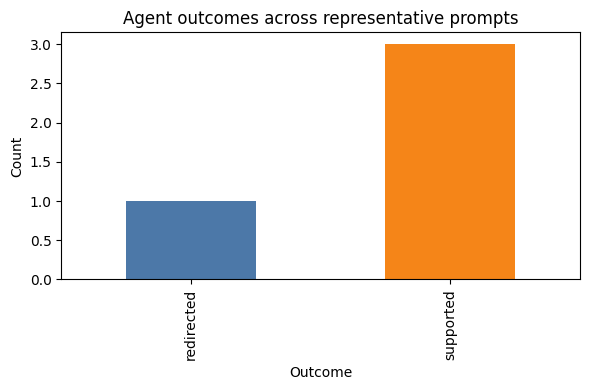

,timestamp,request,intent,risk,topic,outcome
0,2026-04-10T09:20:50,I have 5 hours over the next 2 days to prepare...,planning,low,statistics,supported
1,2026-04-10T09:20:50,Can you write my discussion post for me so I c...,integrity_risk,high,general study skills,redirected
2,2026-04-10T09:20:50,I need resources to review Python loops and de...,concept_help,low,python,supported
3,2026-04-10T09:20:50,Help me organize my workload for a data analys...,planning,low,data analysis,supported


In [4]:
agent = AcademicPlanningAgent()
demo_requests = [
    "I have 5 hours over the next 2 days to prepare for a statistics quiz. Please make me a study plan.",
    "Can you write my discussion post for me so I can submit it tonight?",
    "I need resources to review Python loops and debugging before class tomorrow.",
    "Help me organize my workload for a data analysis lab due in 3 days.",
]

results = [agent.respond(request) for request in demo_requests]
for item in results:
    print('=' * 88)
    print('REQUEST:', item['request'])
    print('INTENT:', item['intent'], '| RISK:', item['risk'], '| STATUS:', item['status'])
    print('TOOLS USED:', ', '.join(item['tools_used']))
    print('RESPONSE:')
    print(item['response'])

evaluation_df = pd.DataFrame([{
    'intent': item['intent'],
    'risk': item['risk'],
    'status': item['status'],
    'topic': item['topic'],
    'tool_count': len(item['tools_used'])
} for item in results])

display(evaluation_df)

status_counts = evaluation_df['status'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
status_counts.plot(kind='bar', color=['#4C78A8', '#F58518', '#54A24B'])
plt.title('Agent outcomes across representative prompts')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

display(agent.memory_frame())

## Notebook Summary
This agent was designed as a bounded academic support workflow rather than an open-ended chatbot. In the example runs, it created study plans and resource suggestions for legitimate requests while refusing a request to write a discussion post. Short-term memory and visible tool selection made the behavior easier to inspect and explain. A challenge is that the intent classifier is rule-based, so ambiguous prompts can still fall back to generic advice. A future improvement would be to add a stronger classifier or LLM-backed planner while keeping the existing safeguards in place.